In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

In [11]:
os.chdir('/Users/cherylxiang/Documents/GitHub/demultiplexing-methods/')
print(os.getcwd())

/Users/cherylxiang/Documents/GitHub/demultiplexing-methods


In [12]:
summary_files = glob.glob('results/**/**/summary.csv', recursive=True)
summary_files = list(set(summary_files))

In [13]:
cher_results = {}
for f in summary_files:
    parts = f.split('/')
    method = parts[1]
    dataset = parts[2]
    df = pd.read_csv(f)
    df = df[df['classification'] != 'total']
    cher_results[f"cher_{method}_{dataset}"] = df

In [14]:
for key, df in cher_results.items():
    print(key)

cher_bffcluster_winkler_pdx1d
cher_demultiplex2_mcginnis_ms
cher_bffraw_winkler_pdx1d
cher_demultiplex_winkler_pdx3b
cher_demultiplex_winkler_pdx1c
cher_demuxmix_mcginnis_hto
cher_hashsolo_winkler_pdx3b
cher_hashsolo_mcginnis_ms
cher_hashsolo_winkler_pdx1a
cher_hashsolo_winkler_pdx3a
cher_demuxmix_mcginnis_ms
cher_hasheddrops_winkler_pdx3b
cher_hasheddrops_winkler_pdx1d
cher_demultiplex_winkler_pdx1d
cher_demultiplex2_winkler_pdx1b
cher_bffraw_winkler_pdx1c
cher_hasheddrops_winkler_pdx3a
cher_demultiplex_mcginnis_ms
cher_demultiplex2_winkler_pdx3b
cher_htodemux_mcginnis_hto
cher_demultiplex_winkler_pdx3a
cher_demultiplex2_winkler_pdx1c
cher_demultiplex_winkler_pdx1a
cher_gmmdemux_mcginnis_hto
cher_demuxmixnaive_mcginnis_ms
cher_bffcluster_winkler_pdx3b
cher_demultiplex2_winkler_pdx1d
cher_hasheddrops_winkler_pdx1b
cher_gmmdemux_winkler_pdx1c
cher_demultiplex_mcginnis_hto
cher_bffraw_winkler_pdx1a
cher_bffraw_winkler_pdx3a
cher_hashsolo_winkler_pdx1c
cher_gmmdemux_winkler_pdx1d
cher_has

In [93]:
#to display dfs
"""for key, df in cher_results.items():
    print(key)
    display(df)"""

'for key, df in cher_results.items():\n    print(key)\n    display(df)'

In [15]:
cher_results['cher_demultiplex_mcginnis_ms']

,classification,n,dataset,method
0,doublet,280,mcginnis_ms,demultiplex
1,negative,323,mcginnis_ms,demultiplex
2,singlet,4556,mcginnis_ms,demultiplex


#### Helper Functions

In [7]:
def create_summary_xcol(calls, method, dataset):
    df = pd.read_csv(calls) 
    df = df.rename(columns={'x': 'classification'})
    df = df.drop(columns=('Unnamed: 0'))

    df['classification'] = df['classification'].replace({
        0: 'negative',
        1000: 'doublet'
    })

    df.loc[~df['classification'].isin(['negative', 'doublet']), 'classification'] = 'singlet'

    summary = df['classification'].value_counts().reset_index()
    summary.columns = ['classification', 'n']
    summary = summary.sort_values(by='n', ascending=True)
    summary['dataset'] = dataset
    summary['method'] = method
    
    return summary

In [8]:
def create_summary(calls, method, dataset):
    df = pd.read_csv(calls) 
    df = df.rename(columns={'Classification': 'classification'})
    df = df.drop(columns=('Unnamed: 0'))

    df['classification'] = df['classification'].replace({
        0: 'negative',
        1000: 'doublet'
    })

    df.loc[~df['classification'].isin(['negative', 'doublet']), 'classification'] = 'singlet'

    summary = df['classification'].value_counts().reset_index()
    summary.columns = ['classification', 'n']
    summary = summary.sort_values(by='n', ascending=True)
    summary['dataset'] = dataset
    summary['method'] = method
    
    return summary

### Dataset 1 Calls Comparison: McGinnis MS

In [16]:
brian_demultiplex_mcginnis_ms = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_ms_demultiplex.csv', 'demultiplex', 'mcginnis_ms')

print('Brian\'s Results:')
display(brian_demultiplex_mcginnis_ms)
print('Cheryl\'s Results:')
display(cher_results['cher_demultiplex_mcginnis_ms'])

Brian's Results:


,classification,n,dataset,method
2,doublet,280,mcginnis_ms,demultiplex
1,negative,323,mcginnis_ms,demultiplex
0,singlet,4556,mcginnis_ms,demultiplex


Cheryl's Results:


,classification,n,dataset,method
0,doublet,280,mcginnis_ms,demultiplex
1,negative,323,mcginnis_ms,demultiplex
2,singlet,4556,mcginnis_ms,demultiplex


In [98]:
brian_demultiplex2_dataset_1 = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_ms_demultiplex2.csv', 'demultiplex2', 'dataset_1')

print('Brian\'s Results:')
display(brian_demultiplex2_dataset_1)
print('Cheryl\'s Results:')
display(cher_results['cher_demultiplex2_dataset_1'])

Brian's Results:


,classification,n,dataset,method
2,negative,88,dataset_1,demultiplex2
1,multiplet,374,dataset_1,demultiplex2
0,singlet,4491,dataset_1,demultiplex2


Cheryl's Results:


,classification,n,dataset,method
0,multiplet,374,dataset_1,demultiplex2
1,negative,294,dataset_1,demultiplex2
2,singlet,4491,dataset_1,demultiplex2


In [99]:
brian_htodemux_dataset_1 = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_ms_htodemux.csv', 'htodemux', 'dataset_1')

print('Brian\'s Results:')
display(brian_htodemux_dataset_1)
print('Cheryl\'s Results:')
display(cher_results['cher_htodemux_dataset_1'])

Brian's Results:


,classification,n,dataset,method
2,negative,317,dataset_1,htodemux
1,multiplet,530,dataset_1,htodemux
0,singlet,4312,dataset_1,htodemux


Cheryl's Results:


,classification,n,dataset,method
0,multiplet,633,dataset_1,htodemux
1,negative,296,dataset_1,htodemux
2,singlet,4230,dataset_1,htodemux


In [100]:
brian_hashsolo_dataset_1 = create_summary('brian-scripts/McGinnis_calls/labels_mcginnis_ms_hsolo.csv', 'hashsolo', 'dataset_1')

print('Brian\'s Results:')
display(brian_hashsolo_dataset_1)
print('Cheryl\'s Results:')
display(cher_results['cher_hashsolo_dataset_1'])

Brian's Results:


,classification,n,dataset,method
2,negative,75,dataset_1,hashsolo
1,multiplet,431,dataset_1,hashsolo
0,singlet,4653,dataset_1,hashsolo


Cheryl's Results:


,classification,n,dataset,method
0,multiplet,431,dataset_1,hashsolo
1,negative,75,dataset_1,hashsolo
2,singlet,4653,dataset_1,hashsolo


In [101]:
brian_bffcluster_dataset_1 = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_ms_bff_cluster.csv', 'bff_cluster', 'dataset_1')

print('Brian\'s Results:')
display(brian_bffcluster_dataset_1)
print('Cheryl\'s Results:')
display(cher_results['cher_bffcluster_dataset_1'])

Brian's Results:


,classification,n,dataset,method
1,multiplet,651,dataset_1,bff_cluster
0,singlet,4508,dataset_1,bff_cluster


Cheryl's Results:


,classification,n,dataset,method
0,multiplet,651,dataset_1,bff_cluster
1,singlet,4508,dataset_1,bff_cluster


In [102]:
brian_bffraw_dataset_1 = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_ms_bff_raw.csv', 'bff_raw', 'dataset_1')

print('Brian\'s Results:')
display(brian_bffraw_dataset_1)
print('Cheryl\'s Results:')
display(cher_results['cher_bffraw_dataset_1'])

Brian's Results:


,classification,n,dataset,method
2,multiplet,253,dataset_1,bff_raw
1,negative,369,dataset_1,bff_raw
0,singlet,4537,dataset_1,bff_raw


Cheryl's Results:


,classification,n,dataset,method
0,multiplet,253,dataset_1,bff_raw
1,negative,369,dataset_1,bff_raw
2,singlet,4537,dataset_1,bff_raw


In [103]:
df = pd.read_csv('brian-scripts/McGinnis_calls/labels_mcginnis_ms_gmmdemux.csv', header=None) 
df = df.rename(columns={0: 'classification'}) 

df['classification'] = df['classification'].replace({
    0: 'negative',
    1000: 'multiplet'
})

df.loc[~df['classification'].isin(['negative', 'multiplet']), 'classification'] = 'singlet'

summary = df['classification'].value_counts().reset_index()
summary.columns = ['classification', 'n']
summary = summary.sort_values(by='n', ascending=True)
summary['dataset'] = 'dataset_1'
summary['method'] = 'gmmdemux'


In [104]:
brian_gmmdemux_dataset_1 = summary

print('Brian\'s Results:')
display(brian_gmmdemux_dataset_1)
print('Cheryl\'s Results:')
display(cher_results['cher_gmmdemux_dataset_1'])

Brian's Results:


,classification,n,dataset,method
2,multiplet,264,dataset_1,gmmdemux
1,negative,387,dataset_1,gmmdemux
0,singlet,4508,dataset_1,gmmdemux


Cheryl's Results:


,classification,n,dataset,method
0,multiplet,283,dataset_1,gmmdemux
1,negative,329,dataset_1,gmmdemux
2,singlet,4547,dataset_1,gmmdemux


In [105]:
brian_hasheddrops_dataset_1 = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_ms_hashed.csv', 'hasheddrops', 'dataset_1')

print('Brian\'s Results:')
display(brian_hasheddrops_dataset_1)
print('Cheryl\'s Results:')
display(cher_results['cher_hasheddrops_dataset_1'])

Brian's Results:


,classification,n,dataset,method
2,negative,365,dataset_1,hasheddrops
1,multiplet,456,dataset_1,hasheddrops
0,singlet,4338,dataset_1,hasheddrops


Cheryl's Results:


,classification,n,dataset,method
0,multiplet,456,dataset_1,hasheddrops
1,negative,365,dataset_1,hasheddrops
2,singlet,4338,dataset_1,hasheddrops


In [106]:
brian_demuxmix_dataset_1 = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_ms_demuxmix.csv', 'demuxmix', 'dataset_1')

print('Brian\'s Results:')
display(brian_demuxmix_dataset_1)
print('Cheryl\'s Results:')
display(cher_results['cher_demuxmix_dataset_1'])

Brian's Results:


,classification,n,dataset,method
2,negative,37,dataset_1,demuxmix
1,multiplet,351,dataset_1,demuxmix
0,singlet,4262,dataset_1,demuxmix


Cheryl's Results:


,classification,n,dataset,method
0,multiplet,351,dataset_1,demuxmix
1,negative,37,dataset_1,demuxmix
2,singlet,4262,dataset_1,demuxmix


In [107]:
brian_demuxmixnaive_dataset_1 = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_ms_demuxmix_naive.csv', 'demuxmix naive', 'dataset_1')

print('Brian\'s Results:')
display(brian_demuxmixnaive_dataset_1)
print('Cheryl\'s Results:')
display(cher_results['cher_demuxmixnaive_dataset_1'])

Brian's Results:


,classification,n,dataset,method
2,negative,37,dataset_1,demuxmix naive
1,multiplet,351,dataset_1,demuxmix naive
0,singlet,4262,dataset_1,demuxmix naive


Cheryl's Results:


,classification,n,dataset,method
0,multiplet,351,dataset_1,demuxmix naive
1,negative,37,dataset_1,demuxmix naive
2,singlet,4262,dataset_1,demuxmix naive


### Dataset 2 Calls Comparison: McGinnis HTO

In [108]:
brian_demultiplex_dataset_2 = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_hto_demultiplex.csv', 'demultiplex', 'dataset_2')

print('Brian\'s Results:')
display(brian_demultiplex_dataset_2)
print('Cheryl\'s Results:')
display(cher_results['cher_demultiplex_dataset_2'])

Brian's Results:


,classification,n,dataset,method
2,multiplet,760,dataset_2,demultiplex
1,negative,1664,dataset_2,demultiplex
0,singlet,2735,dataset_2,demultiplex


Cheryl's Results:


,classification,n,dataset,method
0,multiplet,760,dataset_2,demultiplex
1,negative,1664,dataset_2,demultiplex
2,singlet,2735,dataset_2,demultiplex


In [109]:
brian_demultiplex2_dataset_2 = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_hto_demultiplex2.csv', 'demultiplex2', 'dataset_2')

print('Brian\'s Results:')
display(brian_demultiplex2_dataset_2)
print('Cheryl\'s Results:')
display(cher_results['cher_demultiplex2_dataset_2'])

Brian's Results:


,classification,n,dataset,method
2,multiplet,615,dataset_2,demultiplex2
1,negative,909,dataset_2,demultiplex2
0,singlet,3630,dataset_2,demultiplex2


Cheryl's Results:


,classification,n,dataset,method
0,multiplet,615,dataset_2,demultiplex2
1,negative,914,dataset_2,demultiplex2
2,singlet,3630,dataset_2,demultiplex2


In [110]:
brian_htodemux_dataset_2 = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_hto_htodemux.csv', 'htodemux', 'dataset_2')

#print('Brian\'s Results:')
display(brian_htodemux_dataset_2)
#print('Cheryl\'s Results:')
display(cher_results['cher_htodemux_dataset_2'])

,classification,n,dataset,method
2,singlet,76,dataset_2,htodemux
1,negative,269,dataset_2,htodemux
0,multiplet,4814,dataset_2,htodemux


,classification,n,dataset,method
0,multiplet,4867,dataset_2,htodemux
1,negative,260,dataset_2,htodemux
2,singlet,32,dataset_2,htodemux


In [111]:
brian_hashsolo_dataset_2 = create_summary('brian-scripts/McGinnis_calls/labels_mcginnis_hto_hsolo.csv', 'hashsolo', 'dataset_2')

print('Brian\'s Results:')
display(brian_hashsolo_dataset_2)
print('Cheryl\'s Results:')
display(cher_results['cher_hashsolo_dataset_2'])

Brian's Results:


,classification,n,dataset,method
1,multiplet,302,dataset_2,hashsolo
0,singlet,4857,dataset_2,hashsolo


Cheryl's Results:


,classification,n,dataset,method
0,multiplet,302,dataset_2,hashsolo
1,singlet,4857,dataset_2,hashsolo


In [112]:
brian_bffcluster_dataset_2 = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_hto_bff_cluster.csv', 'bff_cluster', 'dataset_2')

print('Brian\'s Results:')
display(brian_bffcluster_dataset_2)
print('Cheryl\'s Results:')
display(cher_results['cher_bffcluster_dataset_2'])

Brian's Results:


,classification,n,dataset,method
2,negative,5,dataset_2,bff_cluster
1,multiplet,983,dataset_2,bff_cluster
0,singlet,4171,dataset_2,bff_cluster


Cheryl's Results:


,classification,n,dataset,method
0,multiplet,983,dataset_2,bff_cluster
1,negative,5,dataset_2,bff_cluster
2,singlet,4171,dataset_2,bff_cluster


In [113]:
df2 = pd.read_csv('brian-scripts/McGinnis_calls/labels_mcginnis_hto_gmmdemux.csv', header=None) 
df2 = df2.rename(columns={0: 'classification'}) 

df2['classification'] = df2['classification'].replace({
    0: 'negative',
    1000: 'multiplet'
})

df2.loc[~df2['classification'].isin(['negative', 'multiplet']), 'classification'] = 'singlet'

summary2 = df2['classification'].value_counts().reset_index()
summary2.columns = ['classification', 'n']
summary2 = summary2.sort_values(by='n', ascending=True)
summary2['dataset'] = 'dataset_2'
summary2['method'] = 'gmmdemux'

In [114]:
brian_gmmdemux_dataset_2 = summary2

print('Brian\'s Results:')
display(brian_gmmdemux_dataset_2)
print('Cheryl\'s Results:')
display(cher_results['cher_gmmdemux_dataset_2'])

Brian's Results:


,classification,n,dataset,method
1,negative,1787,dataset_2,gmmdemux
0,multiplet,3372,dataset_2,gmmdemux


Cheryl's Results:


,classification,n,dataset,method
0,multiplet,4912,dataset_2,gmmdemux
1,negative,233,dataset_2,gmmdemux
2,singlet,14,dataset_2,gmmdemux


In [115]:
brian_hasheddrops_dataset_2 = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_hto_hashed.csv', 'hasheddrops', 'dataset_2')

print('Brian\'s Results:')
display(brian_hasheddrops_dataset_2)
print('Cheryl\'s Results:')
display(cher_results['cher_hasheddrops_dataset_2'])

Brian's Results:


,classification,n,dataset,method
2,multiplet,454,dataset_2,hasheddrops
1,singlet,1147,dataset_2,hasheddrops
0,negative,3558,dataset_2,hasheddrops


Cheryl's Results:


,classification,n,dataset,method
0,multiplet,454,dataset_2,hasheddrops
1,negative,3558,dataset_2,hasheddrops
2,singlet,1147,dataset_2,hasheddrops


In [116]:
brian_demuxmix_dataset_2 = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_hto_demuxmix.csv', 'demuxmix', 'dataset_2')

print('Brian\'s Results:')
display(brian_demuxmix_dataset_2)
print('Cheryl\'s Results:')
display(cher_results['cher_demuxmix_dataset_2'])

Brian's Results:


,classification,n,dataset,method
2,multiplet,664,dataset_2,demuxmix
1,negative,1421,dataset_2,demuxmix
0,singlet,2565,dataset_2,demuxmix


Cheryl's Results:


,classification,n,dataset,method
0,multiplet,664,dataset_2,demuxmix
1,negative,1421,dataset_2,demuxmix
2,singlet,2565,dataset_2,demuxmix


In [117]:
brian_demuxmixnaive_dataset_2 = create_summary_xcol('brian-scripts/McGinnis_calls/labels_mcginnis_hto_demuxmix_naive.csv', 'demuxmix naive', 'dataset_2')

print('Brian\'s Results:')
display(brian_demuxmixnaive_dataset_2)
print('Cheryl\'s Results:')
display(cher_results['cher_demuxmixnaive_dataset_2'])

Brian's Results:


,classification,n,dataset,method
2,multiplet,664,dataset_2,demuxmix naive
1,negative,1421,dataset_2,demuxmix naive
0,singlet,2565,dataset_2,demuxmix naive


Cheryl's Results:


,classification,n,dataset,method
0,multiplet,664,dataset_2,demuxmix naive
1,negative,1421,dataset_2,demuxmix naive
2,singlet,2565,dataset_2,demuxmix naive


### Winkler Datasets

In [118]:
brian_bffcluster_dataset_3 = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx3b_bff_cluster.csv', 'bff_cluster', 'dataset_3')
brian_bffraw_dataset_3 = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx3b_bff_raw.csv', 'bff_raw', 'dataset_3')
brian_demultiplex_dataset_3 = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx3b_demultiplex.csv', 'demultiplex', 'dataset_3')
brian_demultiplex2_dataset_3 = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx3b_demultiplex2.csv', 'demultiplex2', 'dataset_3')
brian_hasheddrops_dataset_3 = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx3b_hasheddrops.csv', 'hasheddrops', 'dataset_3')
brian_hashsolo_dataset_3 = create_summary('brian-scripts/Winkler_calls/labels_winkler_pdx3b_hashsolo.csv', 'hashsolo', 'dataset_3')
brian_htodemux_dataset_3 = create_summary_xcol('brian-scripts/Winkler_calls/labels_winkler_pdx3b_htodemux.csv', 'htodemux', 'dataset_3')





In [119]:
df2 = pd.read_csv('brian-scripts/Winkler_calls/labels_winkler_pdx3b_gmmdemux.csv', header=None) 
df2 = df2.rename(columns={0: 'classification'}) 

df2['classification'] = df2['classification'].replace({
    0: 'negative',
    1000: 'multiplet'
})

df2.loc[~df2['classification'].isin(['negative', 'multiplet']), 'classification'] = 'singlet'

summary2 = df2['classification'].value_counts().reset_index()
summary2.columns = ['classification', 'n']
summary2 = summary2.sort_values(by='n', ascending=True)
summary2['dataset'] = 'dataset_3'
summary2['method'] = 'gmmdemux'

brian_gmmdemux_dataset_3 = summary2

### Graph Comparisons

In [120]:
brian_results = pd.concat([
    brian_demultiplex_dataset_2,
    brian_bffraw_dataset_1,
    brian_hashsolo_dataset_1,
    brian_bffcluster_dataset_1,
    brian_demuxmixnaive_dataset_2,
    brian_htodemux_dataset_1,
    brian_demuxmix_dataset_1,
    brian_demuxmixnaive_dataset_1,
    brian_gmmdemux_dataset_2,
    brian_demuxmix_dataset_2,
    brian_bffcluster_dataset_2,
    brian_demultiplex2_dataset_2,
    brian_htodemux_dataset_2,
    brian_demultiplex_dataset_1,
    brian_hasheddrops_dataset_2,
    brian_hashsolo_dataset_2,
    brian_hasheddrops_dataset_1,
    brian_demultiplex2_dataset_1,
    brian_gmmdemux_dataset_1,
    brian_bffcluster_dataset_3,
    brian_bffraw_dataset_3,
    brian_demultiplex_dataset_3,
    brian_demultiplex2_dataset_3,
    brian_gmmdemux_dataset_3,
    brian_hasheddrops_dataset_3,
    brian_hashsolo_dataset_3,
    brian_htodemux_dataset_3
], ignore_index=True)

In [121]:
print(brian_results[brian_results['dataset'] == 'dataset_2']['method'].unique())

['demultiplex' 'demuxmix naive' 'gmmdemux' 'demuxmix' 'bff_cluster'
 'demultiplex2' 'htodemux' 'hasheddrops' 'hashsolo']


In [122]:
#read and combine
cher_results = pd.concat([pd.read_csv(f) for f in summary_files], ignore_index=True)

#save combined dataframe
cher_results.to_csv('results/all_results.csv', index=False)

cher_results

,classification,n,dataset,method
0,multiplet,776,dataset_3,hashsolo
1,singlet,2768,dataset_3,hashsolo
2,total,3544,dataset_3,hashsolo
3,multiplet,87,dataset_4,bff_raw
4,negative,2239,dataset_4,bff_raw
...,...,...,...,...
207,total,3532,dataset_4,hashsolo
208,multiplet,1373,dataset_4,bff_cluster
209,negative,14,dataset_4,bff_cluster
210,singlet,2145,dataset_4,bff_cluster


In [123]:
plot_data = cher_results[cher_results['classification'] != 'total'].copy()

datasets = plot_data['dataset'].unique()

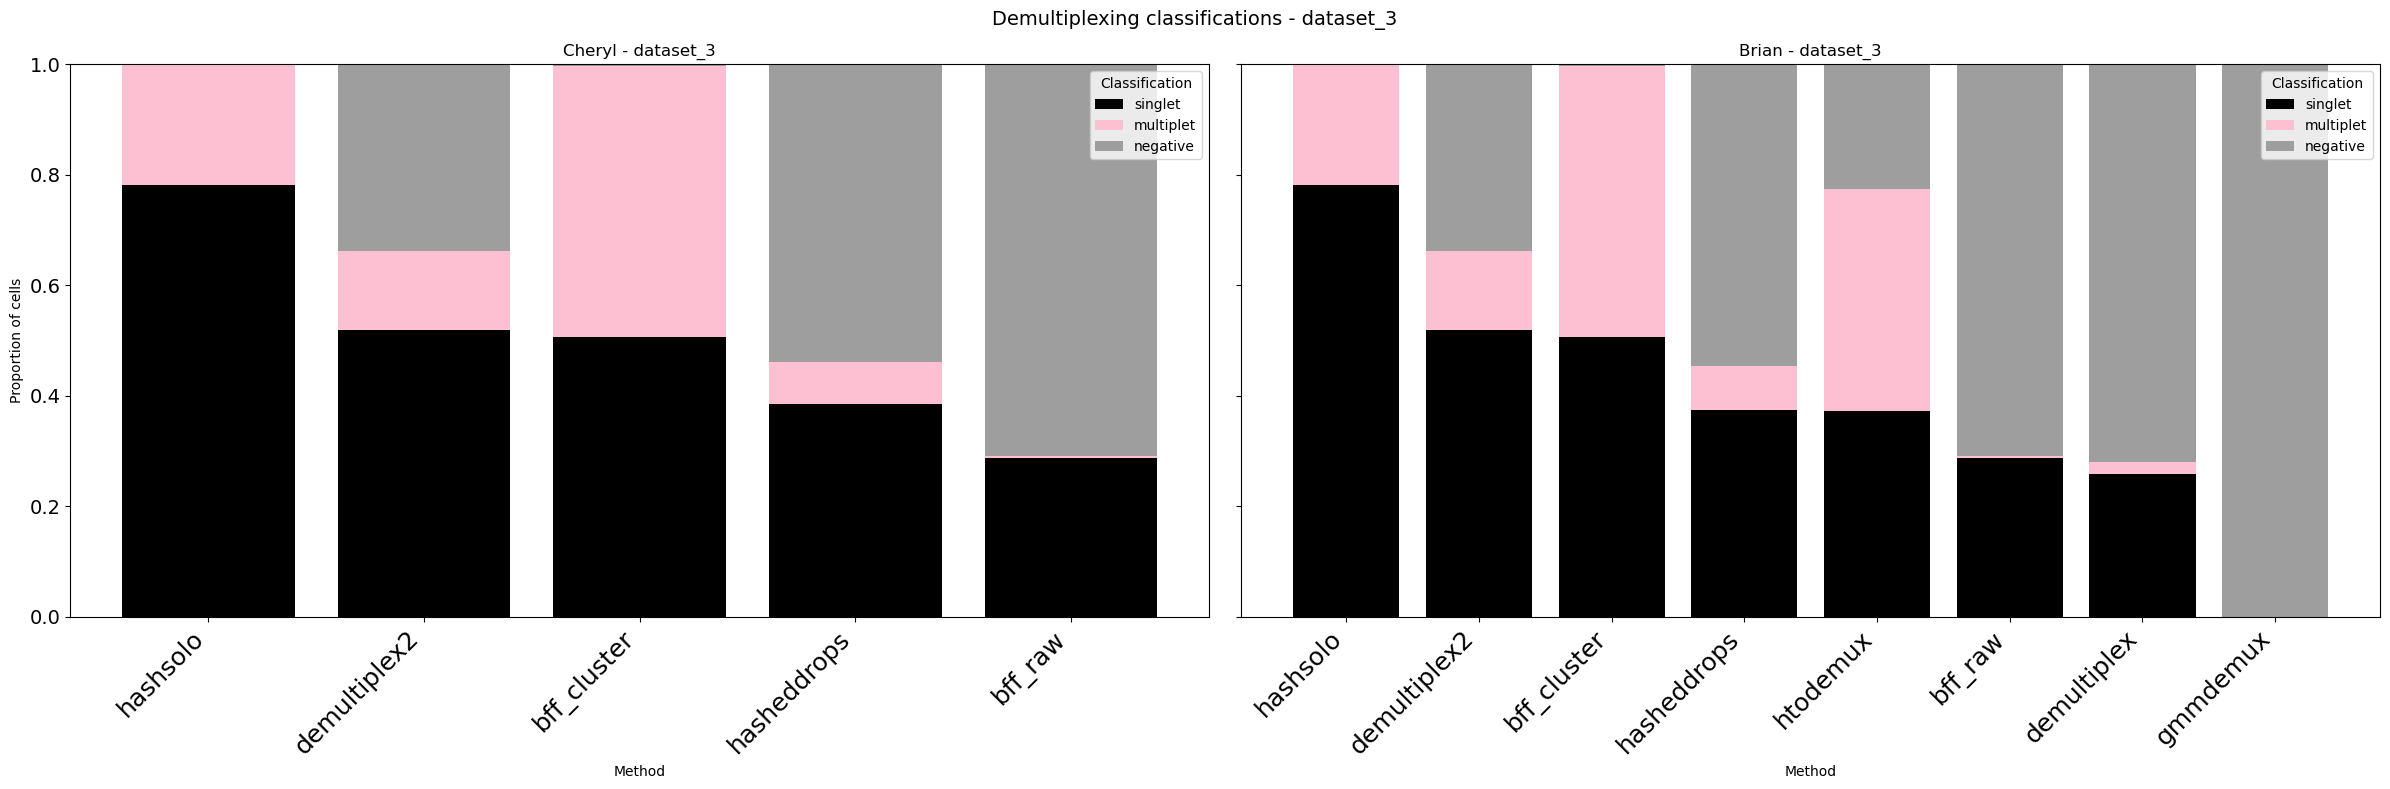

/var/folders/5j/gy3kvrts21bg9h0mjxn2bwww0000gn/T/ipykernel_66940/207119246.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Classification')


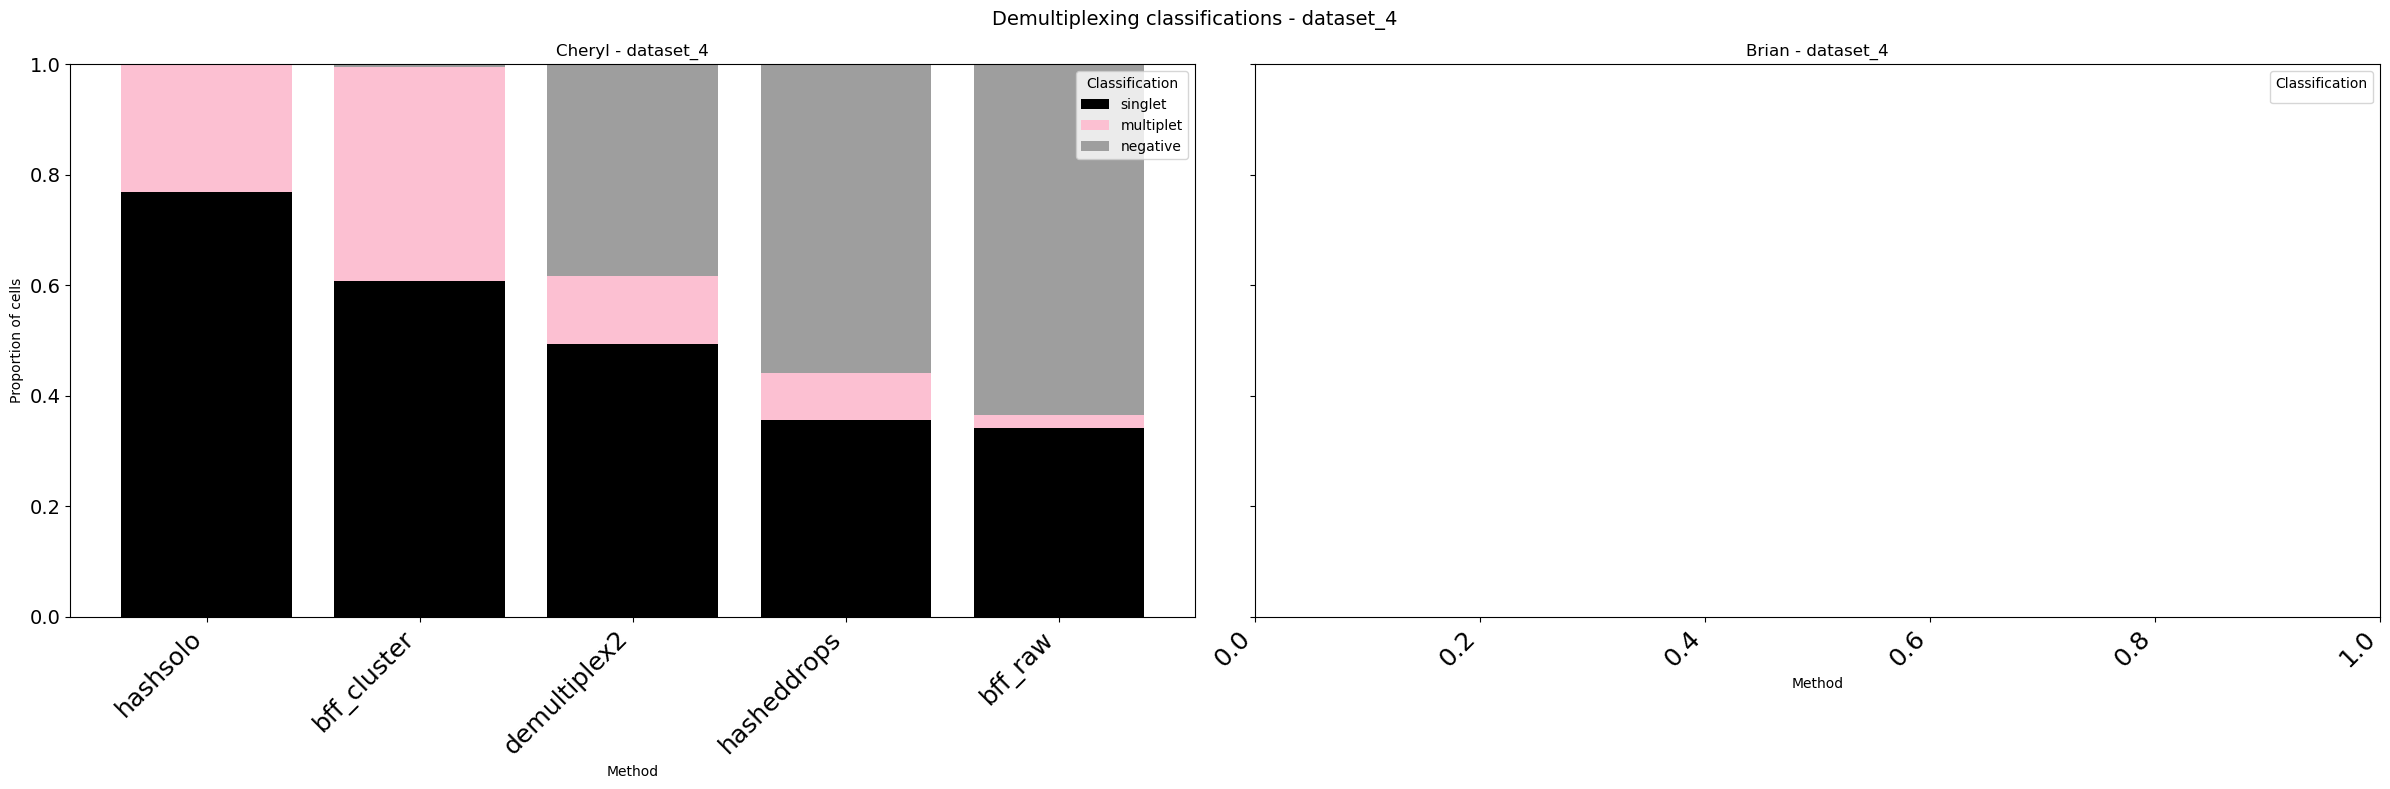

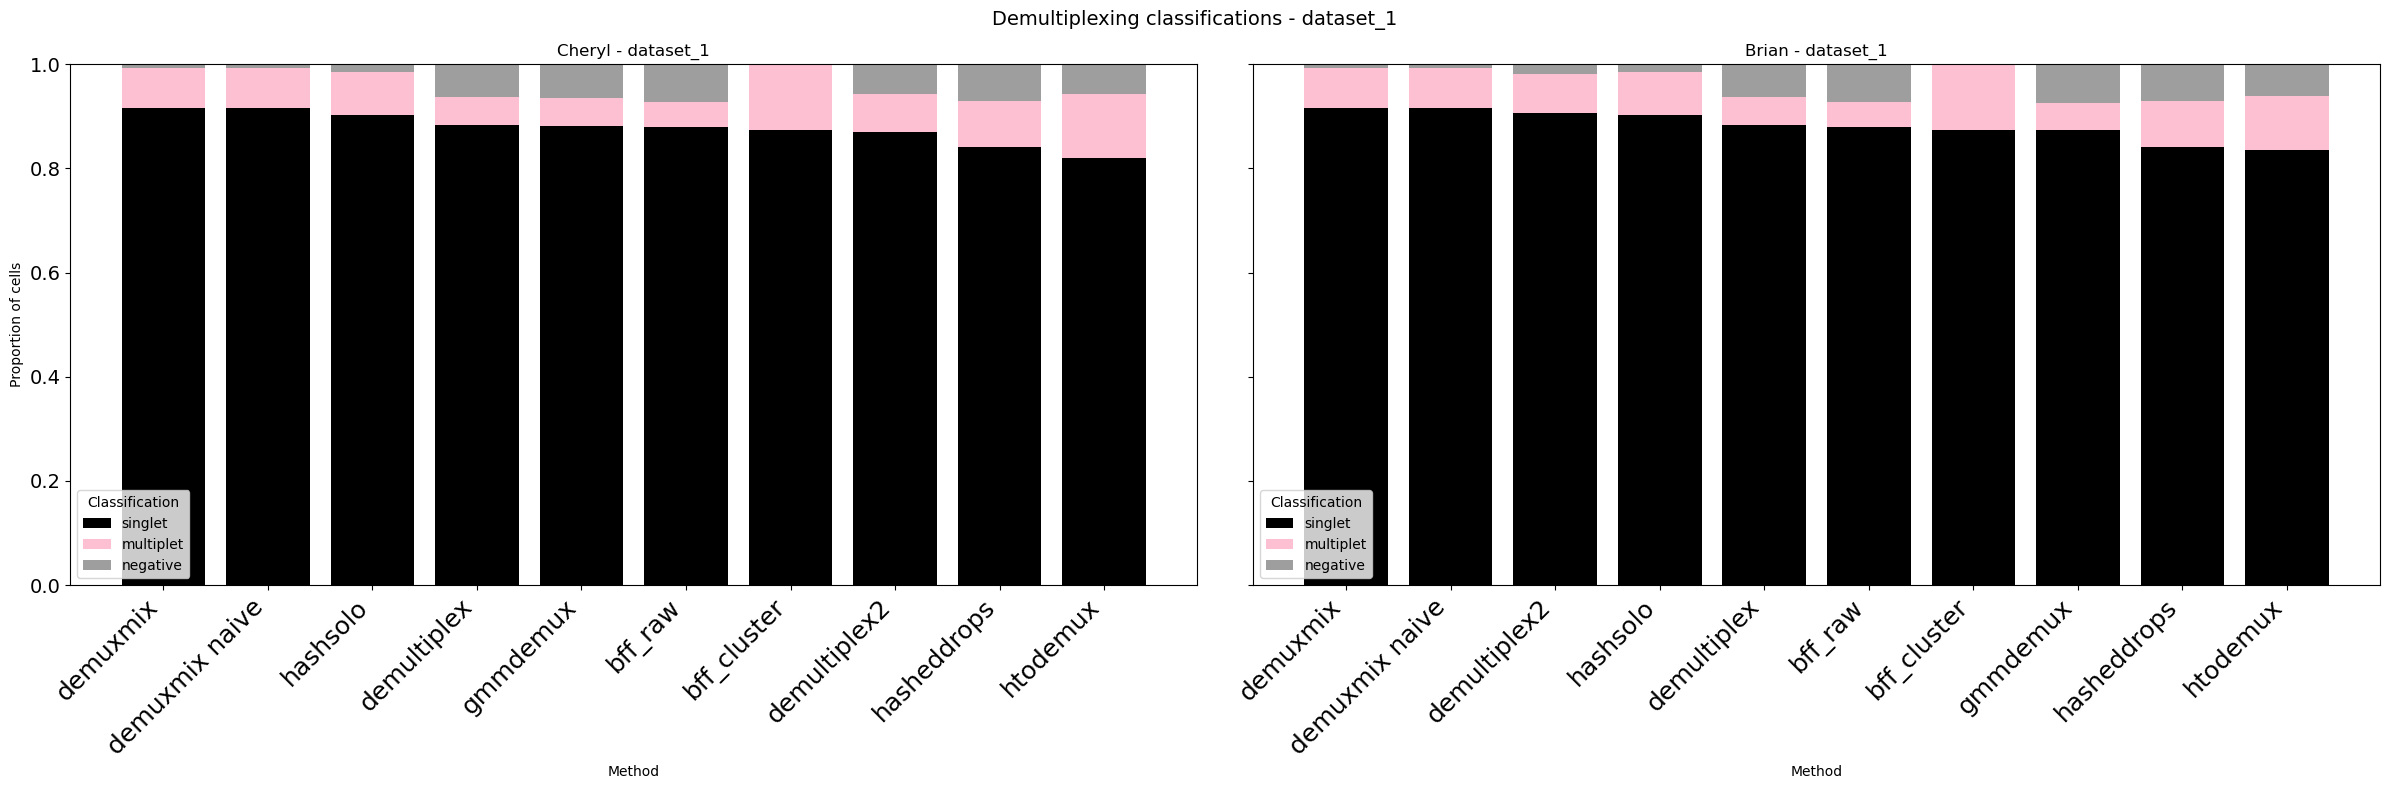

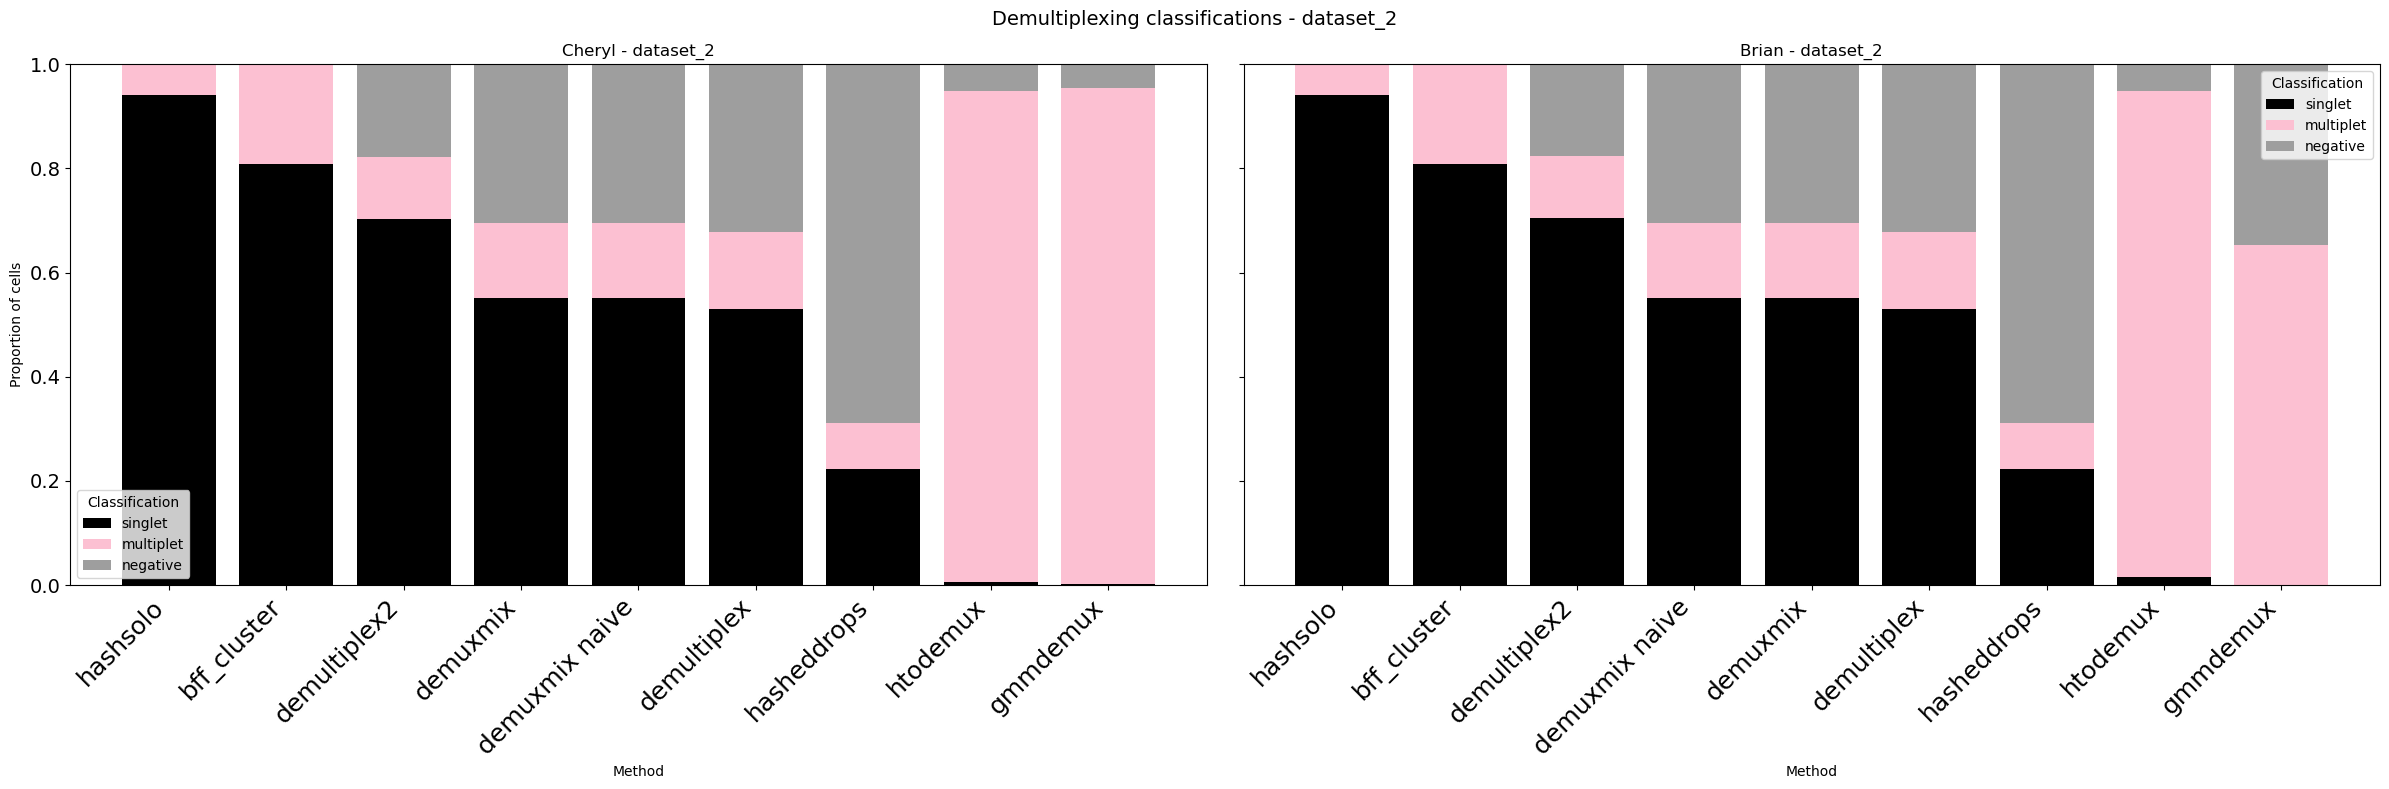

/var/folders/5j/gy3kvrts21bg9h0mjxn2bwww0000gn/T/ipykernel_66940/207119246.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Classification')


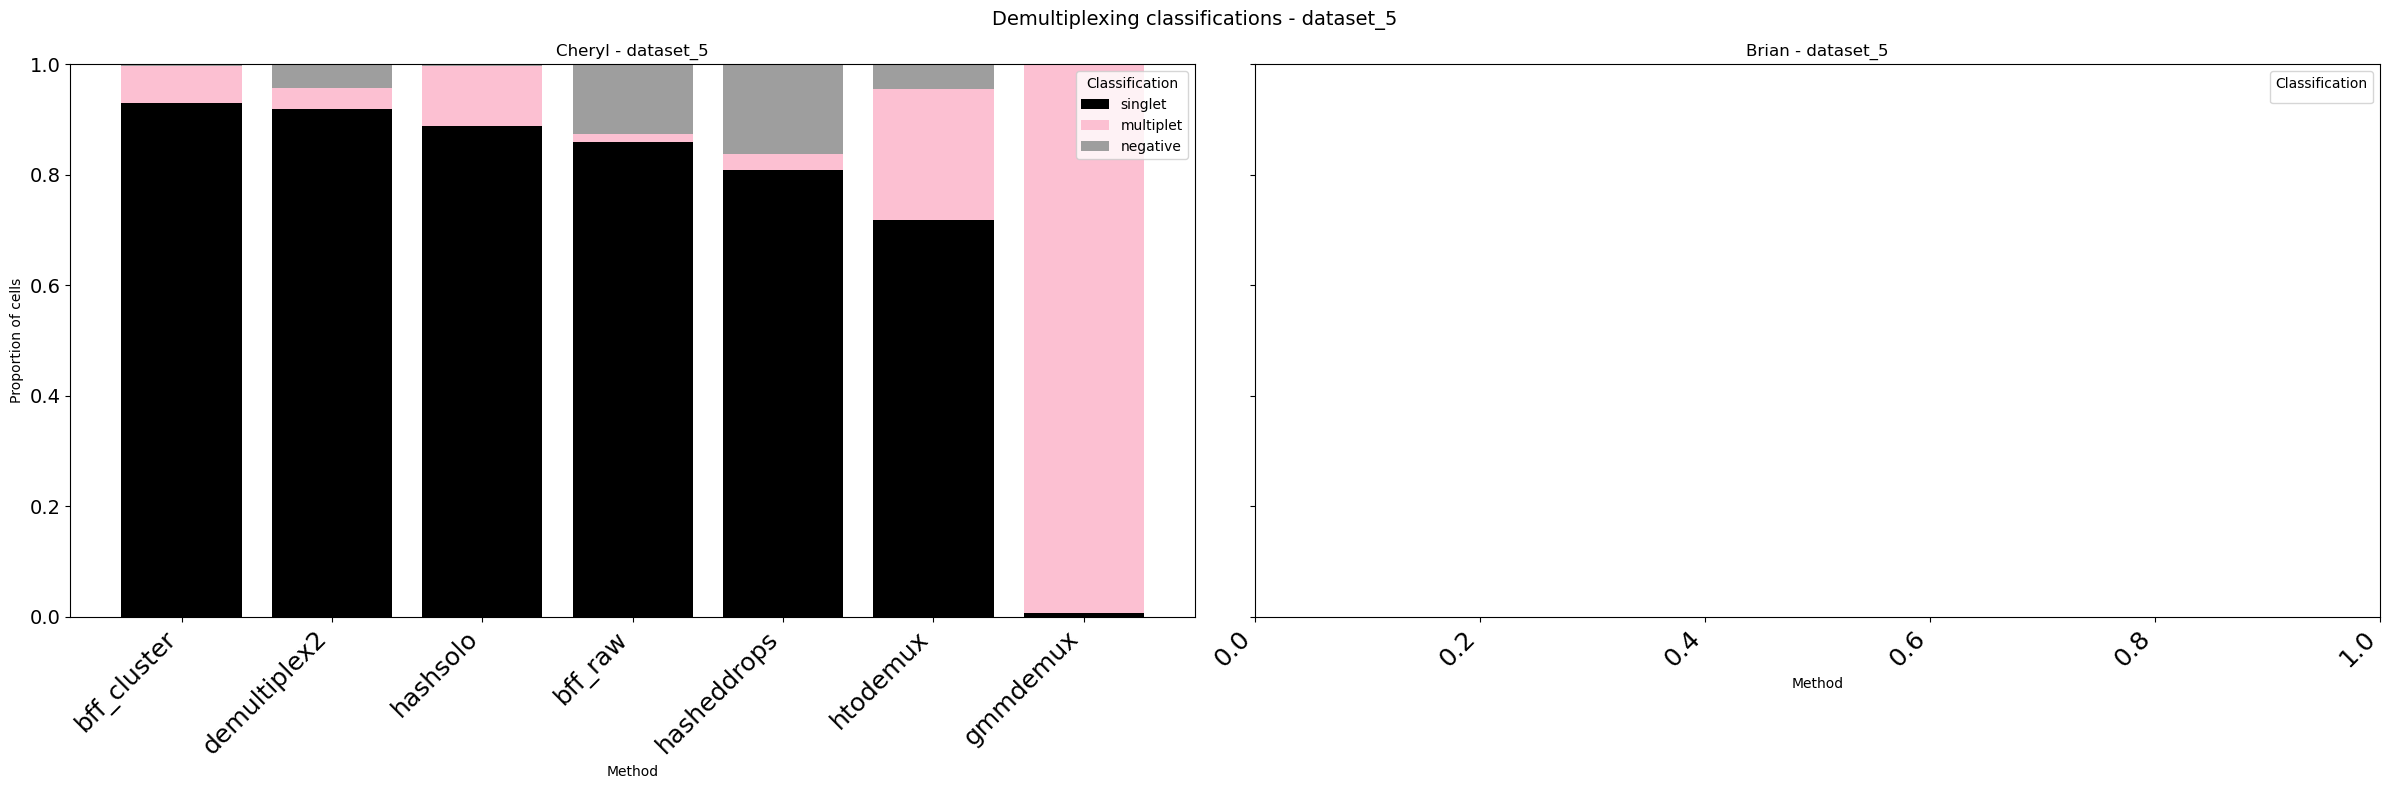

/var/folders/5j/gy3kvrts21bg9h0mjxn2bwww0000gn/T/ipykernel_66940/207119246.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Classification')


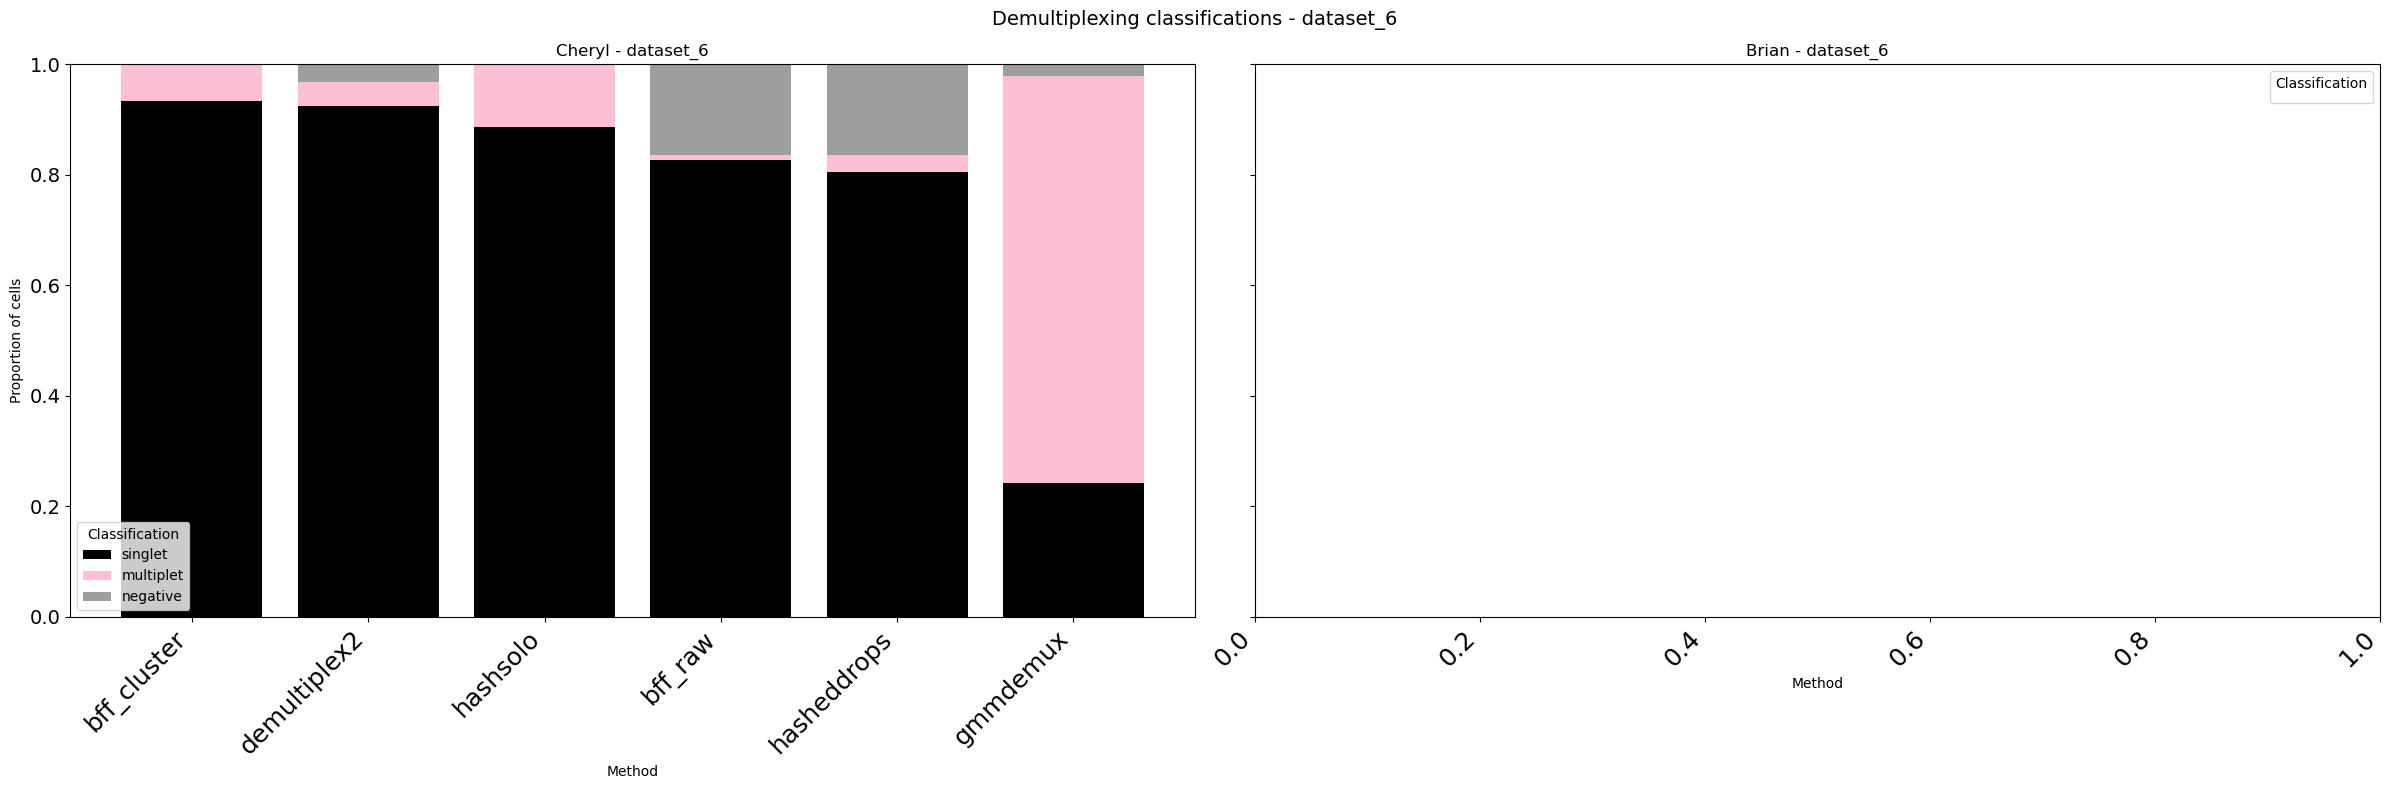

/var/folders/5j/gy3kvrts21bg9h0mjxn2bwww0000gn/T/ipykernel_66940/207119246.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Classification')


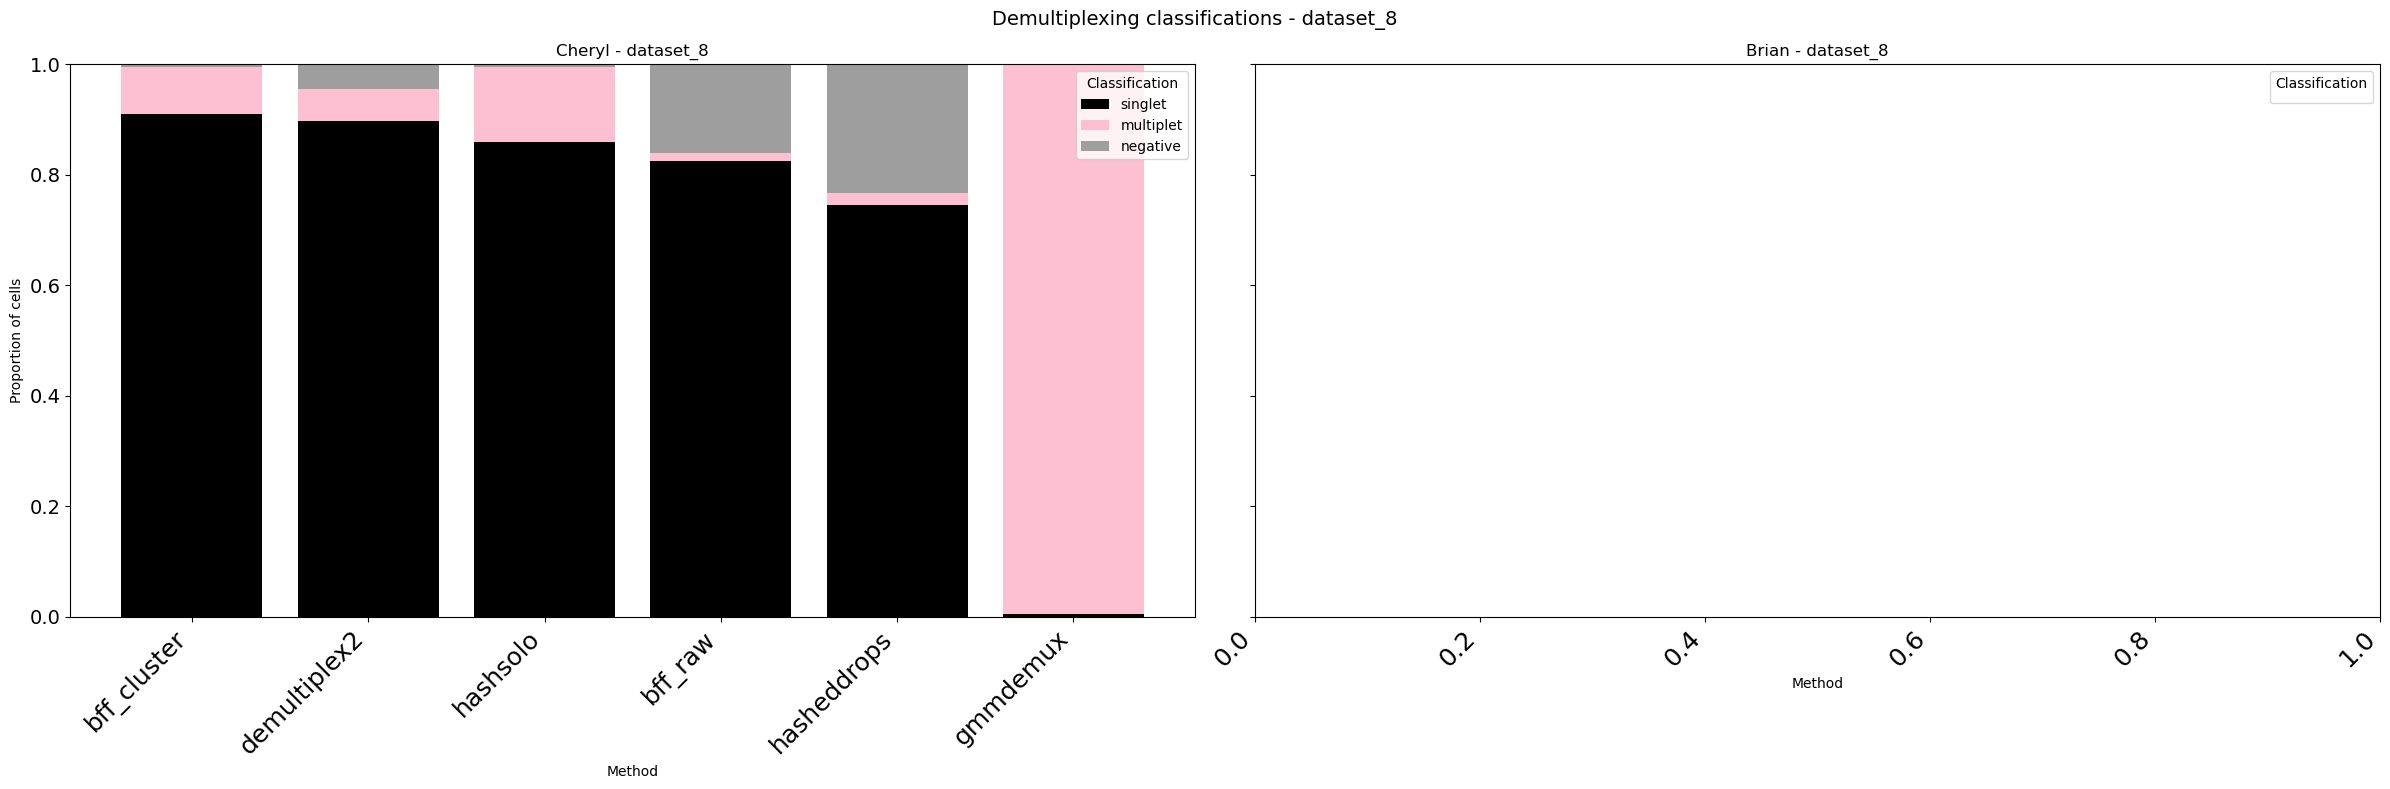

/var/folders/5j/gy3kvrts21bg9h0mjxn2bwww0000gn/T/ipykernel_66940/207119246.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Classification')


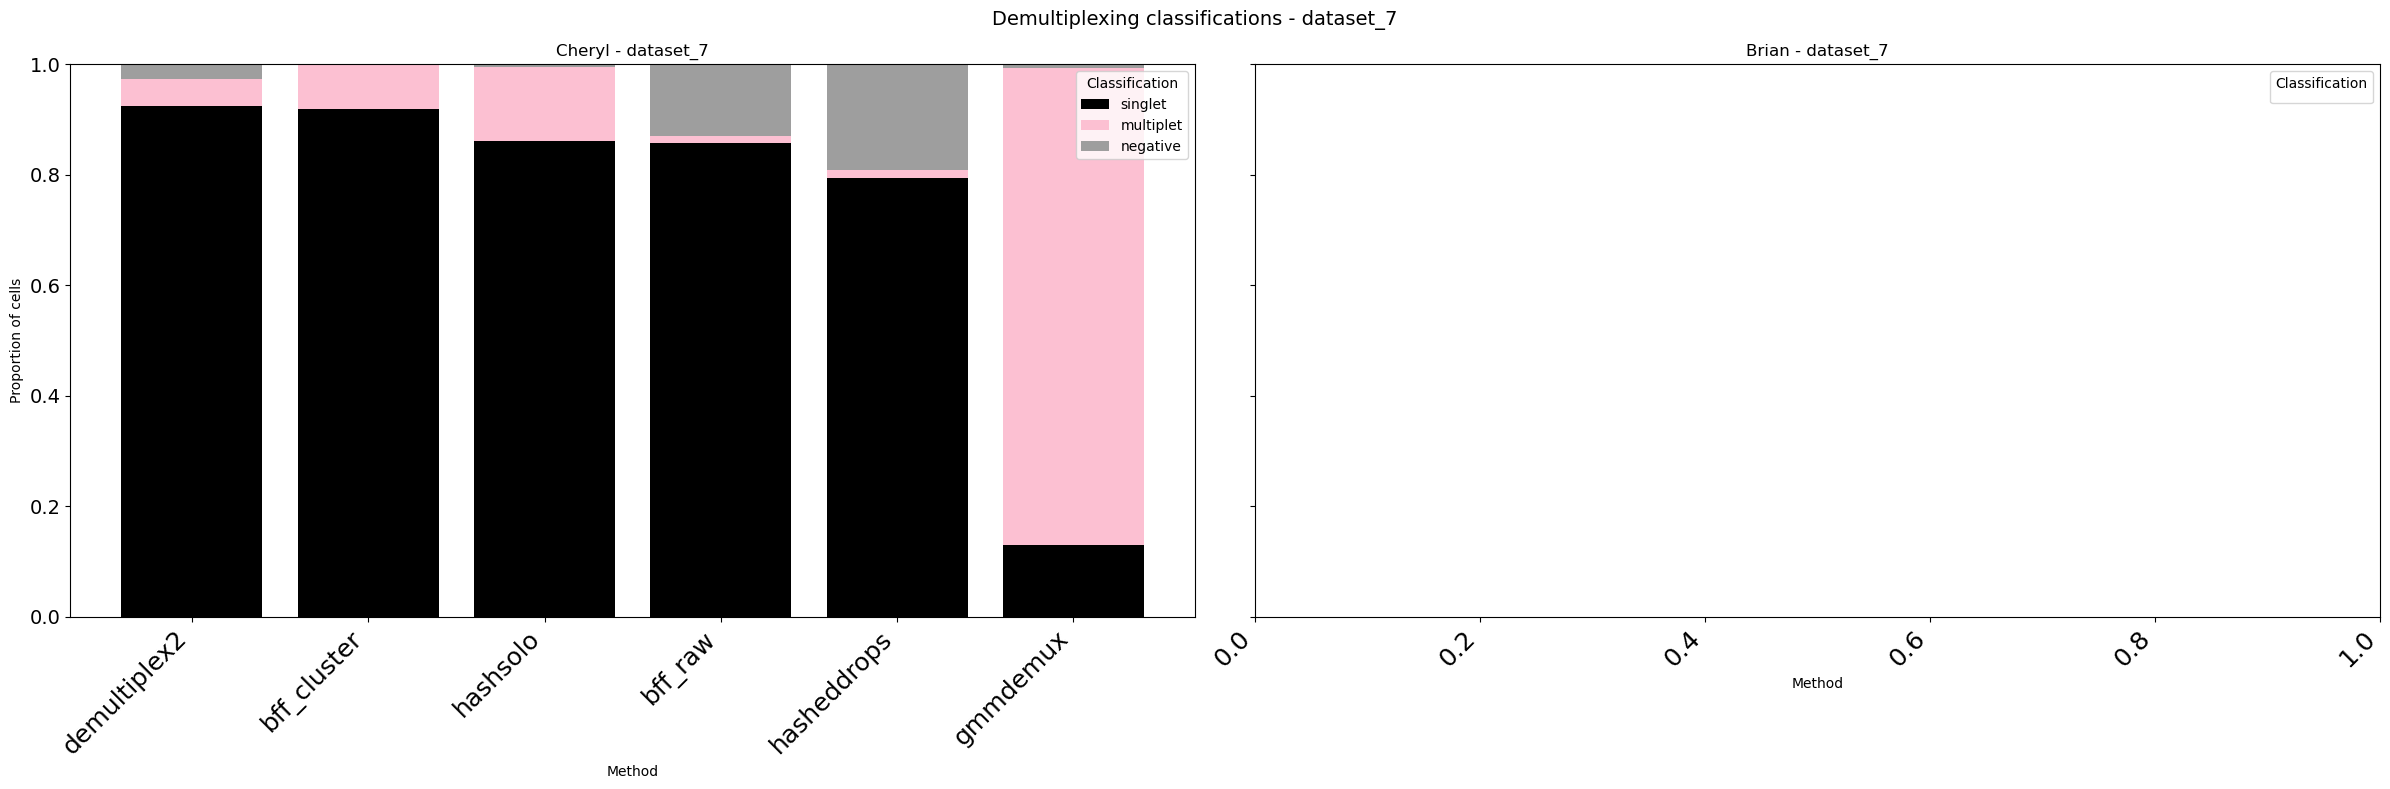

In [124]:
colors = {
    'singlet':  '#000000', 
    'multiplet':  '#fcc0d2', 
    'negative': '#9E9E9E'
}

for dataset in datasets:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 8), sharey=True)
    
    for ax, (data, title) in zip([ax1, ax2], [
        (plot_data[plot_data['dataset'] == dataset], 'Cheryl'),
        (brian_results[brian_results['dataset'] == dataset], 'Brian')
    ]):
        df = data.copy()
        df['proportion'] = df.groupby('method')['n'].transform(lambda x: x / x.sum())

        pivot = df.pivot_table(
            index='method',
            columns='classification',
            values='proportion',
            fill_value=0
        )

        col_order = [c for c in ['singlet', 'multiplet', 'negative'] if c in pivot.columns]
        pivot = pivot[col_order]

        # sort by singlet then multiplet
        sort_order = df[df['classification'] == 'singlet'][['method', 'proportion']].rename(columns={'proportion': 'singlet_prop'})
        # add methods with no singlets with 0 singlet proportion
        all_methods = df['method'].unique()
        missing = pd.DataFrame({
            'method': [m for m in all_methods if m not in sort_order['method'].values],
            'singlet_prop': 0
        })
        sort_order = pd.concat([sort_order, missing], ignore_index=True)

        sort_order = sort_order.sort_values(['singlet_prop'], ascending=[False])
        pivot = pivot.loc[sort_order['method'].tolist()] 

        bottom = pd.Series([0] * len(pivot), index=pivot.index)
        for classification in col_order:
            ax.bar(pivot.index, pivot[classification],
                   bottom=bottom,
                   label=classification,
                   color=colors[classification])
            bottom += pivot[classification]

        ax.set_title(f'{title} - {dataset}')
        ax.set_xlabel('Method')
        ax.set_ylim(0, 1)
        ax.legend(title='Classification')
        ax.tick_params(axis='y', labelsize=14)
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=18)

    ax1.set_ylabel('Proportion of cells')
    plt.suptitle(f'Demultiplexing classifications - {dataset}', fontsize=14)
    plt.tight_layout()

    os.makedirs(f'results/figures/{dataset}', exist_ok=True)
    plt.savefig(f'results/figures/{dataset}/comparison_stacked_bar.pdf')
    plt.show()

In [125]:
# merge summary counts
cher_sample = cher_results[(cher_results['dataset'] == 'dataset_1' ) | (cher_results['dataset'] == 'dataset_2' ) | (cher_results['dataset'] == 'dataset_3' )]
cher_sample = cher_sample[cher_sample['classification'] != 'total']
cher_sample.head()

,classification,n,dataset,method
0,multiplet,776,dataset_3,hashsolo
1,singlet,2768,dataset_3,hashsolo
7,multiplet,651,dataset_1,bff_cluster
8,singlet,4508,dataset_1,bff_cluster
10,multiplet,456,dataset_1,hasheddrops


In [126]:
merged_summary = cher_sample.merge(
    brian_results,
    on=['dataset', 'method', 'classification'],
    suffixes=('_cher', '_brian'),
    how='outer'
).fillna(0)

# keep only rows where counts differ
discrepancies = merged_summary[merged_summary['n_cher'] != merged_summary['n_brian']].copy()
discrepancies['difference'] = discrepancies['n_cher'] - discrepancies['n_brian']

print(f"Total discrepancies: {len(discrepancies)}")
discrepancies.sort_values(['dataset', 'method', 'classification'])

Total discrepancies: 26


,classification,n_cher,dataset,method,n_brian,difference
9,negative,294.0,dataset_1,demultiplex2,88.0,206.0
17,multiplet,283.0,dataset_1,gmmdemux,264.0,19.0
18,negative,329.0,dataset_1,gmmdemux,387.0,-58.0
19,singlet,4547.0,dataset_1,gmmdemux,4508.0,39.0
26,multiplet,633.0,dataset_1,htodemux,530.0,103.0
27,negative,296.0,dataset_1,htodemux,317.0,-21.0
28,singlet,4230.0,dataset_1,htodemux,4312.0,-82.0
36,negative,914.0,dataset_2,demultiplex2,909.0,5.0
44,multiplet,4912.0,dataset_2,gmmdemux,3372.0,1540.0
45,negative,233.0,dataset_2,gmmdemux,1787.0,-1554.0


In [127]:
# pivot to wide format
discrepancies_wide = discrepancies.pivot_table(
    index=['dataset', 'method'],
    columns='classification',
    values='difference',
    fill_value=0
).reset_index()

# flatten column names
#differences measured in cher - brian
discrepancies_wide.columns.name = None
discrepancies_wide = discrepancies_wide.rename(columns={
    'singlet': 'singlet_diff',
    'multiplet': 'multiplet_diff',
    'negative': 'negative_diff'
})

discrepancies_wide = discrepancies_wide.sort_values(['dataset'], ascending=[True])
discrepancies_wide

#only discrepancies are where we decided to change back to using default args

#still need to figure out how to get gmmdemux and demultiplex working on winkler data (here the differences is just whole dataset bc mine DNR)

#I think I am going to go back and rename my datasets because im starting to confuse myself

,dataset,method,multiplet_diff,negative_diff,singlet_diff
0,dataset_1,demultiplex2,0.0,206.0,0.0
1,dataset_1,gmmdemux,19.0,-58.0,39.0
2,dataset_1,htodemux,103.0,-21.0,-82.0
3,dataset_2,demultiplex2,0.0,5.0,0.0
4,dataset_2,gmmdemux,1540.0,-1554.0,14.0
5,dataset_2,htodemux,53.0,-9.0,-44.0
6,dataset_3,demultiplex,-74.0,-2552.0,-918.0
7,dataset_3,gmmdemux,0.0,-3532.0,0.0
8,dataset_3,hasheddrops,-15.0,-23.0,38.0
9,dataset_3,hashsolo,3.0,0.0,-3.0


In [128]:
brian_hasheddrops_dataset_3

,classification,n,dataset,method
2,multiplet,283,dataset_3,hasheddrops
1,singlet,1327,dataset_3,hasheddrops
0,negative,1934,dataset_3,hasheddrops


In [ ]:
#not sure whats going on with the hasheddrops discrepencies since they were the same for mcginnis datasets
cher_results[(cher_results['method'] == 'hasheddrops') & (cher_results['dataset'] == 'dataset_3') & (cher_results['classification'] != 'total')]

,classification,n,dataset,method
153,multiplet,268,dataset_3,hasheddrops
154,negative,1911,dataset_3,hasheddrops
155,singlet,1365,dataset_3,hasheddrops
